# DiffDock Calibration — PoseBusters Benchmark

TARP and MIRA calibration analysis on the 280 PoseBusters complexes for which DiffDock produced predictions (40 samples each).

**TARP ECP above diagonal** = over-dispersed &nbsp;|&nbsp; **below diagonal** = mode-collapsed  
**MIRA reference (S=40)** ≈ 0.683 &nbsp;|&nbsp; **above** = over-dispersed &nbsp;|&nbsp; **below** = mode-collapsed

In [1]:
import sys, warnings, os
sys.path.insert(0, '..')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
from pathlib import Path
matplotlib.rcParams['figure.dpi'] = 120

from utils.tarp_eval import (
    run_tarp_eval, ecp_from_fractions, plot_ecp, atc_score, bootstrap_ecp
)
from utils.mira_eval import compute_mira_scores, mira_null

RESULTS_DIR = "/home/qf226/rds/hpc-work/results/DiffDock/pb_evaluate_v2_merged"
DATA_DIR    = "/home/qf226/rds/hpc-work/data/posebusters_benchmark_set"
METRICS     = os.path.join(RESULTS_DIR, "metrics")
FIGURES     = os.path.join(RESULTS_DIR, "figures")

os.makedirs(METRICS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

results_index = {
    d.name: d
    for d in sorted(Path(RESULTS_DIR).iterdir())
    if d.is_dir() and any(d.glob("rank*.sdf"))
}
complex_names = np.array(sorted(results_index.keys()))
print(f"Complexes with predictions: {len(complex_names)}")

Complexes with predictions: 281


In [2]:
import shutil

# The merge job saves .npy arrays at the root of RESULTS_DIR; cells below
# expect them in METRICS (the metrics/ subdir). Copy once if not already there.
_merged_arrays = [
    "rmsds.npy", "centroid_distances.npy", "confidences.npy",
    "min_self_distances.npy", "run_times.npy", "complex_names.npy",
]
for fname in _merged_arrays:
    src, dst = Path(RESULTS_DIR) / fname, Path(METRICS) / fname
    if src.exists() and not dst.exists():
        shutil.copy2(src, dst)
        print(f"Copied {fname} → metrics/")

# Compute top1_rmsd.npy (confidence-ranked rank-1 RMSD per complex)
_top1_path = Path(METRICS) / "top1_rmsd.npy"
if not _top1_path.exists():
    _rmsds = np.load(Path(METRICS) / "rmsds.npy")
    _confs  = np.load(Path(METRICS) / "confidences.npy")
    _top1   = _rmsds[np.arange(len(_rmsds)), np.argmax(_confs, axis=1)]
    np.save(_top1_path, _top1)
    print(f"Saved top1_rmsd.npy — <2Å: {(_top1 < 2).mean()*100:.1f}%  <5Å: {(_top1 < 5).mean()*100:.1f}%")
else:
    print("top1_rmsd.npy already exists")

top1_rmsd.npy already exists


In [3]:

# inference.py doesn't write complex_names.npy — create it from the results index
names_path = f"{METRICS}/complex_names.npy"
if not os.path.exists(names_path):
    np.save(names_path, complex_names)
    print(f"Saved complex_names.npy ({len(complex_names)} complexes)")
else:
    print(f"complex_names.npy already exists ({len(complex_names)} complexes)")


complex_names.npy already exists (281 complexes)


## TARP — Centroid (fast)

Represents each pose as its ligand centroid (3D). Tests whether DiffDock samples the correct binding-site region. K=100 reference points, ~10 seconds on CPU.

Loaded cached centroid TARP (281 complexes)


ATC score (centroid): +0.0178
  (+ = over-dispersed, - = mode-collapsed, 0 = perfect)


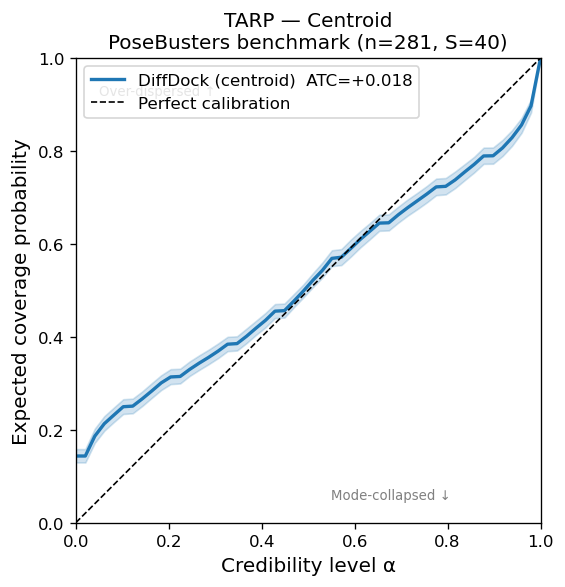

In [4]:
CENTROID_CACHE = f"{METRICS}/tarp_fractions_centroid.npy"

if os.path.exists(CENTROID_CACHE):
    f_centroid = np.load(CENTROID_CACHE)
    print(f"Loaded cached centroid TARP ({f_centroid.shape[0]} complexes)")
else:
    f_centroid = run_tarp_eval(
        complex_names, results_index, DATA_DIR,
        K=100, mode="centroid", seed=42, verbose=True, n_workers=1
    )
    np.save(CENTROID_CACHE, f_centroid)

ecp_c, alpha_c = ecp_from_fractions(f_centroid, n_bins=50)
boot_c = bootstrap_ecp(f_centroid, n_bootstrap=500)
atc_c  = atc_score(ecp_c, alpha_c)
print(f"ATC score (centroid): {atc_c:+.4f}")
print(f"  (+ = over-dispersed, - = mode-collapsed, 0 = perfect)")

fig, ax = plt.subplots(figsize=(5, 5))
plot_ecp(ecp_c, alpha_c, ax=ax,
         label=f"DiffDock (centroid)  ATC={atc_c:+.3f}",
         color="C0", bootstrap_ecps=boot_c)
ax.set_title(f"TARP — Centroid\nPoseBusters benchmark (n={len(complex_names)}, S=40)")
plt.tight_layout()
plt.savefig(f"{FIGURES}/tarp_ecp_centroid.png", dpi=150, bbox_inches='tight')
plt.show()

## TARP — Full RMSD

Uses symmetry-corrected RMSD over all heavy atoms. Tests full 3D pose calibration including orientation and torsion angles.

> Set `K_RMSD = 100` for publication-quality results (run on a compute node, ~20–40 min).

Loaded cached RMSD TARP K=1 (281 complexes)
ATC score (RMSD, K=1): +0.0136


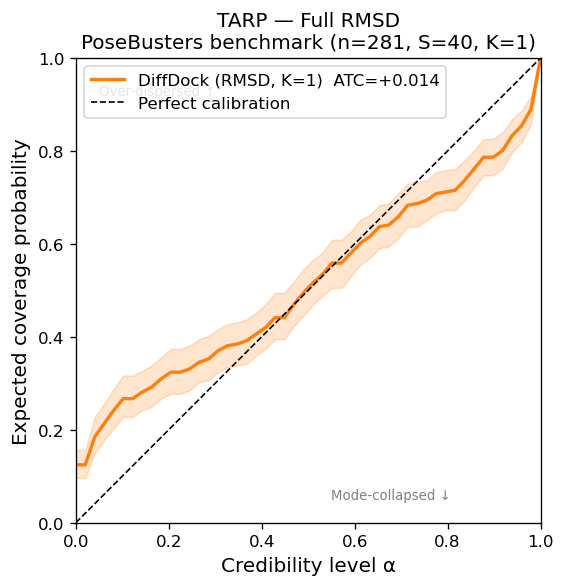

In [5]:
K_RMSD = 1

RMSD_CACHE = f"{METRICS}/tarp_fractions_rmsd_K{K_RMSD}.npy"

if os.path.exists(RMSD_CACHE):
    f_rmsd = np.load(RMSD_CACHE)
    print(f"Loaded cached RMSD TARP K={K_RMSD} ({f_rmsd.shape[0]} complexes)")
else:
    f_rmsd = run_tarp_eval(
        complex_names, results_index, DATA_DIR,
        K=K_RMSD, mode="rmsd", seed=42, verbose=True, n_workers=1
    )
    np.save(RMSD_CACHE, f_rmsd)

ecp_r, alpha_r = ecp_from_fractions(f_rmsd, n_bins=50)
boot_r = bootstrap_ecp(f_rmsd, n_bootstrap=500)
atc_r  = atc_score(ecp_r, alpha_r)
print(f"ATC score (RMSD, K={K_RMSD}): {atc_r:+.4f}")

fig, ax = plt.subplots(figsize=(5, 5))
plot_ecp(ecp_r, alpha_r, ax=ax,
         label=f"DiffDock (RMSD, K={K_RMSD})  ATC={atc_r:+.3f}",
         color="C1", bootstrap_ecps=boot_r)
ax.set_title(f"TARP — Full RMSD\nPoseBusters benchmark (n={len(complex_names)}, S=40, K={K_RMSD})")
plt.tight_layout()
plt.savefig(f"{FIGURES}/tarp_ecp_rmsd.png", dpi=150, bbox_inches='tight')
plt.show()

## TARP — Combined plot

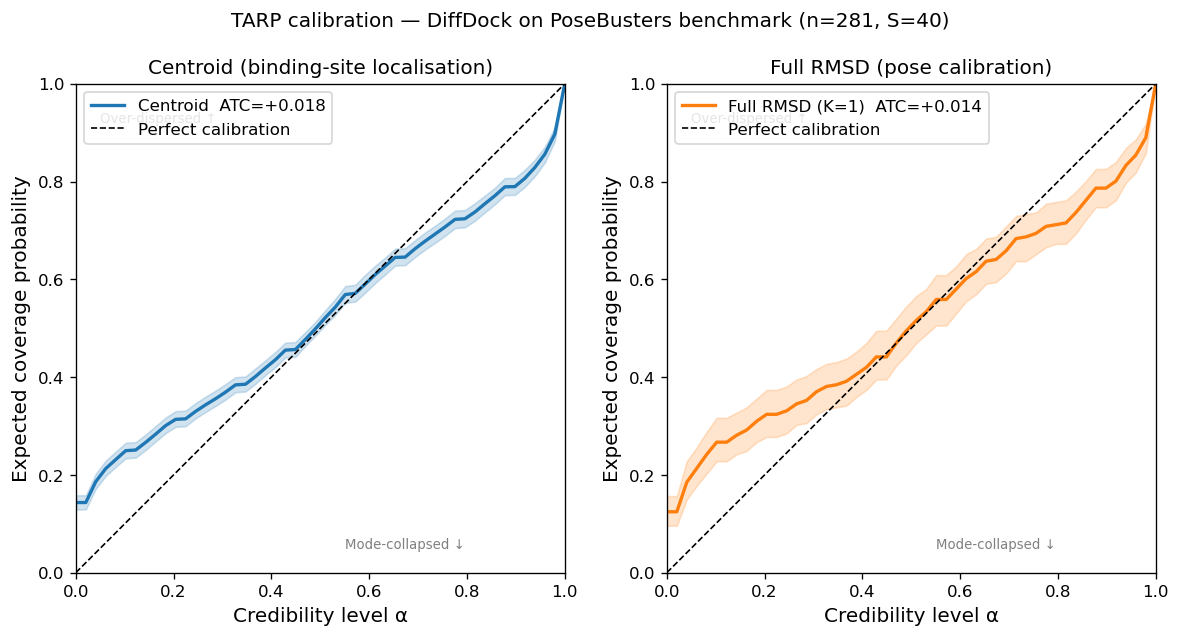

ATC centroid: +0.0178
ATC RMSD:     +0.0136


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_ecp(ecp_c, alpha_c, ax=axes[0], label=f"Centroid  ATC={atc_c:+.3f}",
         color="C0", bootstrap_ecps=boot_c)
axes[0].set_title("Centroid (binding-site localisation)")

plot_ecp(ecp_r, alpha_r, ax=axes[1], label=f"Full RMSD (K={K_RMSD})  ATC={atc_r:+.3f}",
         color="C1", bootstrap_ecps=boot_r)
axes[1].set_title("Full RMSD (pose calibration)")

plt.suptitle(
    f"TARP calibration — DiffDock on PoseBusters benchmark (n={len(complex_names)}, S=40)",
    y=1.02
)
plt.tight_layout()
plt.savefig(f"{FIGURES}/tarp_ecp_combined.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"ATC centroid: {atc_c:+.4f}")
print(f"ATC RMSD:     {atc_r:+.4f}")

## MIRA Score

MIRA draws random centers in coordinate space and checks whether the crystal pose falls inside the same ball as DiffDock's predicted samples.

**Reference (S=40) ≈ 0.683** — above = over-dispersed, below = mode-collapsed.

In [7]:
MIRA_SCORES_PATH = f"{METRICS}/mira_scores_rmsd.npy"
MIRA_NAMES_PATH  = f"{METRICS}/mira_names_rmsd.npy"
REF = mira_null(S=40)

if os.path.exists(MIRA_SCORES_PATH):
    mira_names  = np.load(MIRA_NAMES_PATH,  allow_pickle=True)
    mira_scores = np.load(MIRA_SCORES_PATH)
    print(f"Loaded cached MIRA scores ({len(mira_scores)} complexes)")
else:
    mira_names, mira_scores = compute_mira_scores(
        complex_names, results_index, DATA_DIR,
        num_runs=100, verbose=True, metric="rmsd",
    )
    np.save(MIRA_NAMES_PATH,  mira_names)
    np.save(MIRA_SCORES_PATH, mira_scores)

print(f"\nOverall MIRA score:              {mira_scores.mean():.4f} ± {mira_scores.std():.4f}")
print(f"Reference (perfect calib, S=40): {REF:.4f}")
print(f"Deviation from reference:        {mira_scores.mean() - REF:+.4f}")

Loaded cached MIRA scores (281 complexes)

Overall MIRA score:              0.6353 ± 0.0863
Reference (perfect calib, S=40): 0.6833
Deviation from reference:        -0.0481


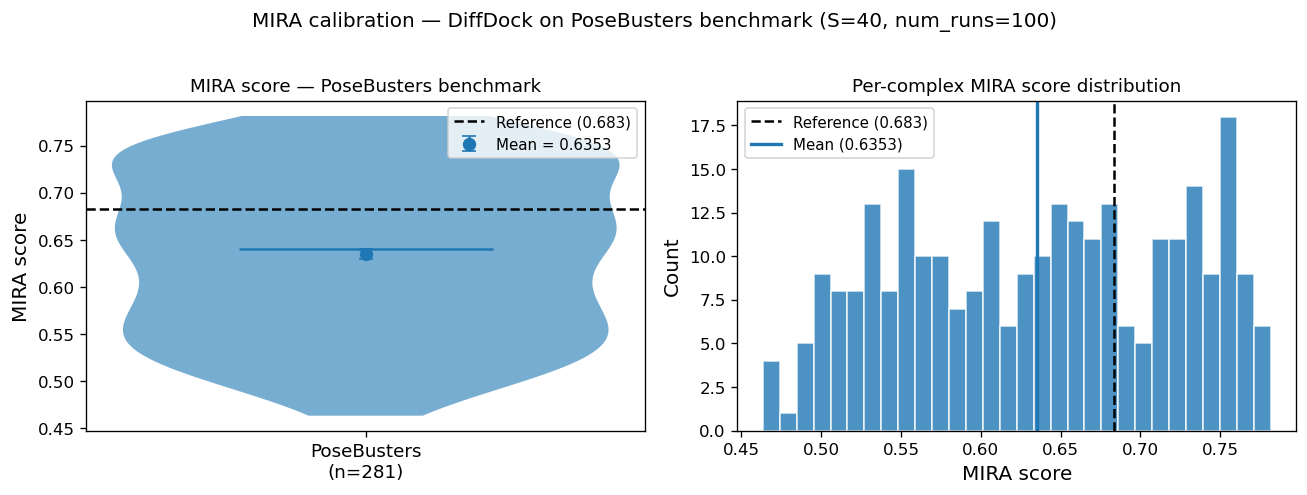

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: violin + mean ± SEM
ax = axes[0]
vp = ax.violinplot([mira_scores], positions=[0], showmedians=True, showextrema=False)
vp["bodies"][0].set_facecolor("C0")
vp["bodies"][0].set_alpha(0.6)
ax.errorbar(0, mira_scores.mean(),
            yerr=mira_scores.std() / np.sqrt(len(mira_scores)),
            fmt="o", color="C0", capsize=4, ms=7, zorder=5,
            label=f"Mean = {mira_scores.mean():.4f}")
ax.axhline(REF, color="k", ls="--", lw=1.5, label=f"Reference ({REF:.3f})")
ax.set_xticks([0])
ax.set_xticklabels([f"PoseBusters\n(n={len(mira_scores)})"], fontsize=11)
ax.set_ylabel("MIRA score", fontsize=12)
ax.set_title("MIRA score — PoseBusters benchmark", fontsize=11)
ax.legend(fontsize=9)

# Right: per-complex histogram
ax2 = axes[1]
ax2.hist(mira_scores, bins=30, color="C0", edgecolor="white", alpha=0.8)
ax2.axvline(REF, color="k", ls="--", lw=1.5, label=f"Reference ({REF:.3f})")
ax2.axvline(mira_scores.mean(), color="C0", ls="-", lw=2,
            label=f"Mean ({mira_scores.mean():.4f})")
ax2.set_xlabel("MIRA score", fontsize=12)
ax2.set_ylabel("Count", fontsize=12)
ax2.set_title("Per-complex MIRA score distribution", fontsize=11)
ax2.legend(fontsize=9)

plt.suptitle(
    f"MIRA calibration — DiffDock on PoseBusters benchmark (S=40, num_runs=100)",
    y=1.02
)
plt.tight_layout()
plt.savefig(f"{FIGURES}/mira_score.png", dpi=150, bbox_inches='tight')
plt.show()

## Pose counts per complex

## Docking accuracy — PoseBusters vs PDBBind test set

Symmetry-corrected RMSD (spyrmsd) of DiffDock rank-1 and all 40 poses against the crystal structure. Results compared to the PDBBind test set to contextualise accuracy on this harder, post-2021 benchmark.

Dataset               n   Top-1<2Å   Top-1<5Å   Best<2Å   Best<5Å   Med.RMSD
---------------------------------------------------------------------------
PoseBusters         281      54.1%      75.1%     63.0%     85.1%      1.55Å
PDBBind test        322      40.4%      54.7%     57.1%     78.3%      3.72Å


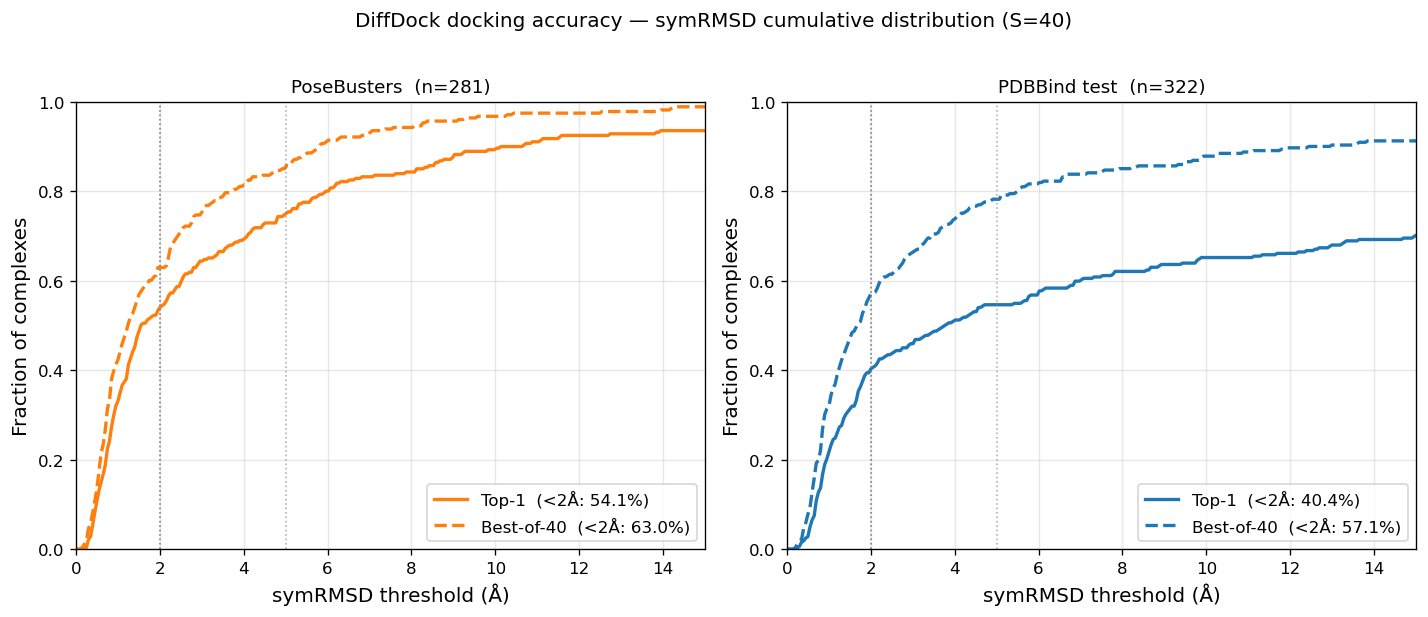

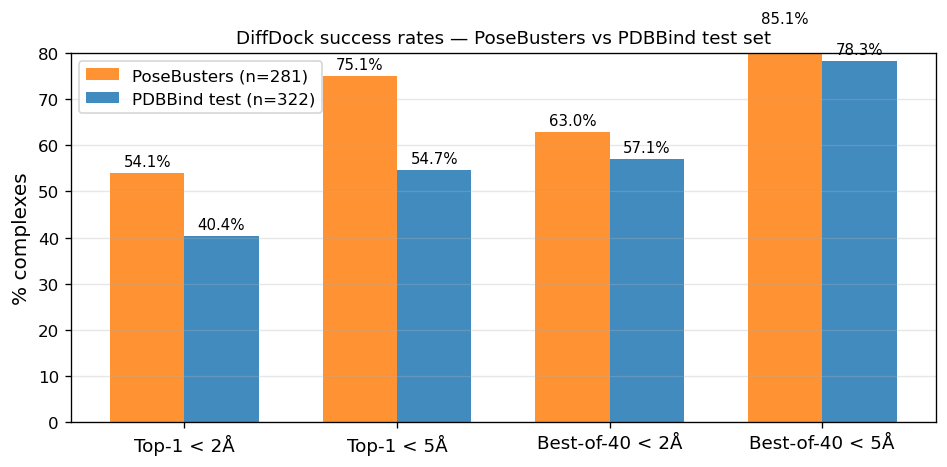

In [9]:
if "METRICS" not in dir():
    import sys, os
    sys.path.insert(0, '..')
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib
    from pathlib import Path
    matplotlib.rcParams['figure.dpi'] = 120

    RESULTS_DIR = "../results/posebusters_inference"
    METRICS     = os.path.join(RESULTS_DIR, "metrics")
    FIGURES     = os.path.join(RESULTS_DIR, "figures")
    os.makedirs(FIGURES, exist_ok=True)

PDBBIND_METRICS = "/home/qf226/rds/hpc-work/results/DiffDock/pdbbind_testset/metrics"

# ── Load RMSD arrays ─────────────────────────────────────────────────────────
pb_top1  = np.load(f"{METRICS}/top1_rmsd.npy")
pb_rmsds = np.load(f"{METRICS}/rmsds.npy")          # (n_complexes, 40)
pb_best  = np.nanmin(pb_rmsds, axis=1)

pdb_top1  = np.load(f"{PDBBIND_METRICS}/top1_rmsd.npy")
pdb_rmsds = np.load(f"{PDBBIND_METRICS}/rmsds.npy")
pdb_best  = np.nanmin(pdb_rmsds, axis=1)

S = pb_rmsds.shape[1]

# ── Print summary table ──────────────────────────────────────────────────────
datasets = [("PoseBusters", pb_top1, pb_best), ("PDBBind test", pdb_top1, pdb_best)]
print(f"{'Dataset':<18} {'n':>4}  {'Top-1<2Å':>9}  {'Top-1<5Å':>9}  {'Best<2Å':>8}  {'Best<5Å':>8}  {'Med.RMSD':>9}")
print("-" * 75)
for name, top1, best in datasets:
    print(f"{name:<18} {len(top1):>4}  "
          f"{(top1<2).mean()*100:>8.1f}%  "
          f"{(top1<5).mean()*100:>8.1f}%  "
          f"{(best<2).mean()*100:>7.1f}%  "
          f"{(best<5).mean()*100:>7.1f}%  "
          f"{np.nanmedian(top1):>8.2f}Å")

# ── Cumulative RMSD curves ───────────────────────────────────────────────────
thresholds = np.linspace(0, 15, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (top1, best, label, color) in zip(
    axes,
    [(pb_top1,  pb_best,  "PoseBusters",  "C1"),
     (pdb_top1, pdb_best, "PDBBind test", "C0")],
):
    frac_top1 = [(top1 < t).mean() for t in thresholds]
    frac_best = [(best < t).mean() for t in thresholds]
    ax.plot(thresholds, frac_top1, color=color, lw=2,
            label=f"Top-1  (<2Å: {(top1<2).mean()*100:.1f}%)")
    ax.plot(thresholds, frac_best, color=color, lw=2, ls="--",
            label=f"Best-of-{S}  (<2Å: {(best<2).mean()*100:.1f}%)")
    ax.axvline(2, color="grey", ls=":", lw=1)
    ax.axvline(5, color="grey", ls=":", lw=1, alpha=0.6)
    ax.set_xlim(0, 15)
    ax.set_ylim(0, 1)
    ax.set_xlabel("symRMSD threshold (Å)", fontsize=12)
    ax.set_ylabel("Fraction of complexes", fontsize=12)
    ax.set_title(f"{label}  (n={len(top1)})", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle(
    f"DiffDock docking accuracy — symRMSD cumulative distribution (S={S})",
    y=1.02, fontsize=12
)
plt.tight_layout()
plt.savefig(f"{FIGURES}/rmsd_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Bar chart: 2Å / 5Å success rates ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
bar_labels = ["Top-1 < 2Å", "Top-1 < 5Å", f"Best-of-{S} < 2Å", f"Best-of-{S} < 5Å"]
pb_vals  = [(pb_top1  < 2).mean()*100, (pb_top1  < 5).mean()*100,
            (pb_best  < 2).mean()*100, (pb_best  < 5).mean()*100]
pdb_vals = [(pdb_top1 < 2).mean()*100, (pdb_top1 < 5).mean()*100,
            (pdb_best < 2).mean()*100, (pdb_best < 5).mean()*100]
x = np.arange(len(bar_labels))
w = 0.35
bars1 = ax.bar(x - w/2, pb_vals,  w, label=f"PoseBusters (n={len(pb_top1)})",  color="C1", alpha=0.85)
bars2 = ax.bar(x + w/2, pdb_vals, w, label=f"PDBBind test (n={len(pdb_top1)})", color="C0", alpha=0.85)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(bar_labels, fontsize=11)
ax.set_ylabel("% complexes", fontsize=12)
ax.set_ylim(0, 80)
ax.set_title("DiffDock success rates — PoseBusters vs PDBBind test set", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES}/rmsd_accuracy_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## Accuracy after PoseBusters filtering

How much does requiring physically valid poses change the docking accuracy? Best-of-N is recomputed over the PB-valid subset only; Top-1 metrics check whether the confidence-ranked best pose is itself physically valid.

Loaded PB results: 281 complexes
  [0/281] 5SAK_ZRY ...


  [20/281] 6YRV_PJ8 ...


  [40/281] 7B94_ANP ...


  [60/281] 7DUA_HJ0 ...


  [80/281] 7KM8_WPD ...


...

  [220/281] 7WKL_CAQ ...


  [240/281] 7ZDY_6MJ ...


  [260/281] 8C5M_MTA ...


  [280/281] 8SLG_G5A ...


Done. 178 complexes evaluated, 103 skipped (no PB-valid poses or missing crystal).
  Best-of-valid acc (<2Å): 0.624 | Any-valid acc: 0.438
  Best-of-valid acc (<5Å): 0.758 | Any-valid acc: 0.580

Performance impact of PoseBusters filtering

  Best-of-40 RMSD < 2 Å:   63.0%  →  62.4%  (Δ = -0.6%)
  Best-of-40 RMSD < 5 Å:   85.1%  →  75.8%  (Δ = -9.2%)

  Top-1 RMSD < 2 Å (all complexes):          54.1%
  Top-1 PB-valid AND RMSD < 2 Å:              22.8%  (Δ = -31.3%)

  Top-1 poses that are PB-valid:              37.7%
  Complexes with ≥1 PB-valid pose:            63.3%

  Overall PB pass rate:                       2792/11196 = 24.9%


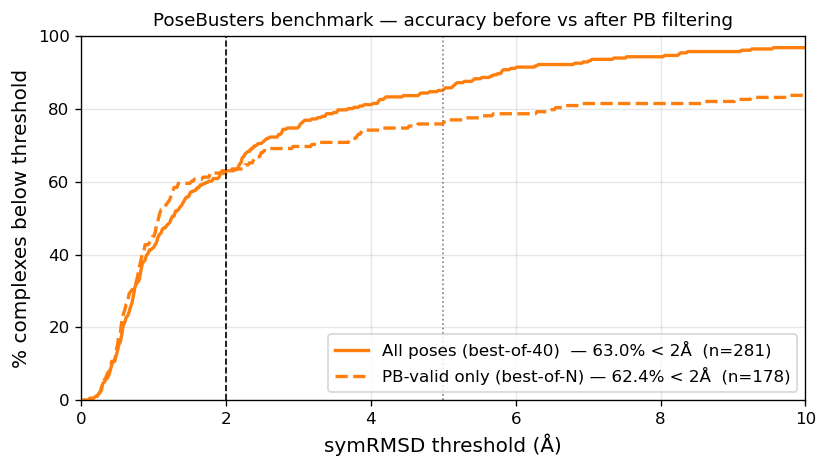

In [10]:
import json
from utils.posebusters_eval import compute_rmsd_accuracy_filtered

PB_CACHE      = f"{METRICS}/posebusters_results_pb.json"
PB_RMSD_CACHE = f"{METRICS}/pb_rmsd_accuracy.npz"

# Load PB results — guard against stale empty cache written by a failed run
pb_results = {}
if os.path.exists(PB_CACHE):
    with open(PB_CACHE) as f:
        pb_results = json.load(f)

if len(pb_results) == 0:
    print("WARNING: PoseBusters results cache is empty or missing — skipping this cell.")
    print(f"  Run the PB filtering job first, then re-execute.")
    print(f"  Cache path: {PB_CACHE}")
else:
    print(f"Loaded PB results: {len(pb_results)} complexes")

    # ── Compute (or load) PB-filtered best-of-N RMSD ────────────────────────────
    if os.path.exists(PB_RMSD_CACHE):
        _d = np.load(PB_RMSD_CACHE, allow_pickle=True)
        pb_acc_names = _d["names"]
        pb_acc_min   = _d["min_rmsds"]
        print(f"Loaded cached PB-filtered RMSD ({len(pb_acc_names)} complexes)")
    else:
        pb_acc_names, pb_acc_min, _ = compute_rmsd_accuracy_filtered(
            complex_names, pb_results, RESULTS_DIR, DATA_DIR,
            thresholds=(2.0, 5.0), verbose=True,
        )
        np.savez(PB_RMSD_CACHE, names=pb_acc_names, min_rmsds=pb_acc_min)

    # ── Top-1 validity flags (over all complexes) ────────────────────────────────
    top1_valid = np.array([
        "rank1.sdf" in pb_results.get(n, {}).get("valid_ranks", [])
        for n in complex_names
    ])

    # ── Before / after numbers ───────────────────────────────────────────────────
    S = pb_rmsds.shape[1]
    before_2 = (pb_best  < 2.0).mean() * 100
    before_5 = (pb_best  < 5.0).mean() * 100
    after_2  = (pb_acc_min < 2.0).mean() * 100
    after_5  = (pb_acc_min < 5.0).mean() * 100

    top1_acc_before = (pb_top1 < 2.0).mean() * 100
    top1_acc_after  = (top1_valid & (pb_top1 < 2.0)).mean() * 100

    n_any_valid = sum(1 for v in pb_results.values() if v.get("valid_ranks"))
    total_valid = sum(len(v.get("valid_ranks", [])) for v in pb_results.values())
    total_poses = sum(v.get("n_total", 0) for v in pb_results.values())

    print("\nPerformance impact of PoseBusters filtering")
    print("=" * 52)
    print(f"\n  Best-of-{S} RMSD < 2 Å:   {before_2:.1f}%  →  {after_2:.1f}%  (Δ = {after_2-before_2:+.1f}%)")
    print(f"  Best-of-{S} RMSD < 5 Å:   {before_5:.1f}%  →  {after_5:.1f}%  (Δ = {after_5-before_5:+.1f}%)")
    print(f"\n  Top-1 RMSD < 2 Å (all complexes):          {top1_acc_before:.1f}%")
    print(f"  Top-1 PB-valid AND RMSD < 2 Å:              {top1_acc_after:.1f}%  (Δ = {top1_acc_after-top1_acc_before:+.1f}%)")
    print(f"\n  Top-1 poses that are PB-valid:              {top1_valid.mean()*100:.1f}%")
    print(f"  Complexes with ≥1 PB-valid pose:            {n_any_valid/len(pb_results)*100:.1f}%")
    print(f"\n  Overall PB pass rate:                       {total_valid}/{total_poses} = {100*total_valid/total_poses:.1f}%")

    # ── CDF: before vs after PB filter ──────────────────────────────────────────
    thresholds = np.linspace(0, 10, 500)
    before_cdf = np.array([(pb_best    < t).mean() for t in thresholds]) * 100
    after_cdf  = np.array([(pb_acc_min < t).mean() for t in thresholds]) * 100

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(thresholds, before_cdf, color="C1", lw=2,
            label=f"All poses (best-of-{S})  — {before_2:.1f}% < 2Å  (n={len(pb_best)})")
    ax.plot(thresholds, after_cdf,  color="C1", lw=2, ls="--",
            label=f"PB-valid only (best-of-N) — {after_2:.1f}% < 2Å  (n={len(pb_acc_min)})")
    ax.axvline(2, color="k",    ls="--", lw=1)
    ax.axvline(5, color="grey", ls=":",  lw=1)
    ax.set_xlabel("symRMSD threshold (Å)", fontsize=12)
    ax.set_ylabel("% complexes below threshold", fontsize=12)
    ax.set_title("PoseBusters benchmark — accuracy before vs after PB filtering", fontsize=11)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/pb_rmsd_accuracy_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

[15:13:12] ERROR: Cannot process coordinates on line 5
[15:13:12] ERROR: moving to the beginning of the next molecule
[15:13:12] ERROR: Cannot process coordinates on line 5
[15:13:12] ERROR: moving to the beginning of the next molecule
[15:13:12] ERROR: Cannot process coordinates on line 5
[15:13:12] ERROR: moving to the beginning of the next molecule
[15:13:12] ERROR: Cannot process coordinates on line 5
[15:13:12] ERROR: moving to the beginning of the next molecule
[15:13:12] ERROR: Cannot process coordinates on line 5
[15:13:12] ERROR: moving to the beginning of the next molecule
[15:13:12] ERROR: Cannot process coordinates on line 5
[15:13:12] ERROR: moving to the beginning of the next molecule


[15:13:12] ERROR: Cannot process coordinates on line 5
[15:13:12] ERROR: moving to the beginning of the next molecule
[15:13:13] ERROR: Cannot process coordinates on line 5
[15:13:13] ERROR: moving to the beginning of the next molecule
[15:13:13] ERROR: Cannot process coordinates on line 5
[15:13:13] ERROR: moving to the beginning of the next molecule
[15:13:13] ERROR: Cannot process coordinates on line 5
[15:13:13] ERROR: moving to the beginning of the next molecule
[15:13:13] ERROR: Cannot process coordinates on line 5
[15:13:13] ERROR: moving to the beginning of the next molecule


[15:13:13] ERROR: Cannot process coordinates on line 5
[15:13:13] ERROR: moving to the beginning of the next molecule


[15:13:47] ERROR: Cannot convert 'P ' to into on line 5
[15:13:47] ERROR: moving to the beginning of the next molecule


[15:14:21] ERROR: Cannot process coordinates on line 5
[15:14:21] ERROR: moving to the beginning of the next molecule
[15:14:21] ERROR: Cannot process coordinates on line 5
[15:14:21] ERROR: moving to the beginning of the next molecule
[15:14:21] ERROR: Cannot process coordinates on line 5
[15:14:21] ERROR: moving to the beginning of the next molecule


...

[15:17:41] ERROR: Cannot process coordinates on line 5
[15:17:41] ERROR: moving to the beginning of the next molecule


[15:18:50] ERROR: Cannot process coordinates on line 5
[15:18:50] ERROR: moving to the beginning of the next molecule
[15:18:50] ERROR: Cannot process coordinates on line 5
[15:18:50] ERROR: moving to the beginning of the next molecule


[15:19:25] ERROR: Cannot process coordinates on line 5
[15:19:25] ERROR: moving to the beginning of the next molecule
[15:19:25] ERROR: Cannot process coordinates on line 5
[15:19:25] ERROR: moving to the beginning of the next molecule


[15:19:42] ERROR: Cannot process coordinates on line 5
[15:19:42] ERROR: moving to the beginning of the next molecule


[15:19:55] ERROR: Cannot process coordinates on line 5
[15:19:55] ERROR: moving to the beginning of the next molecule


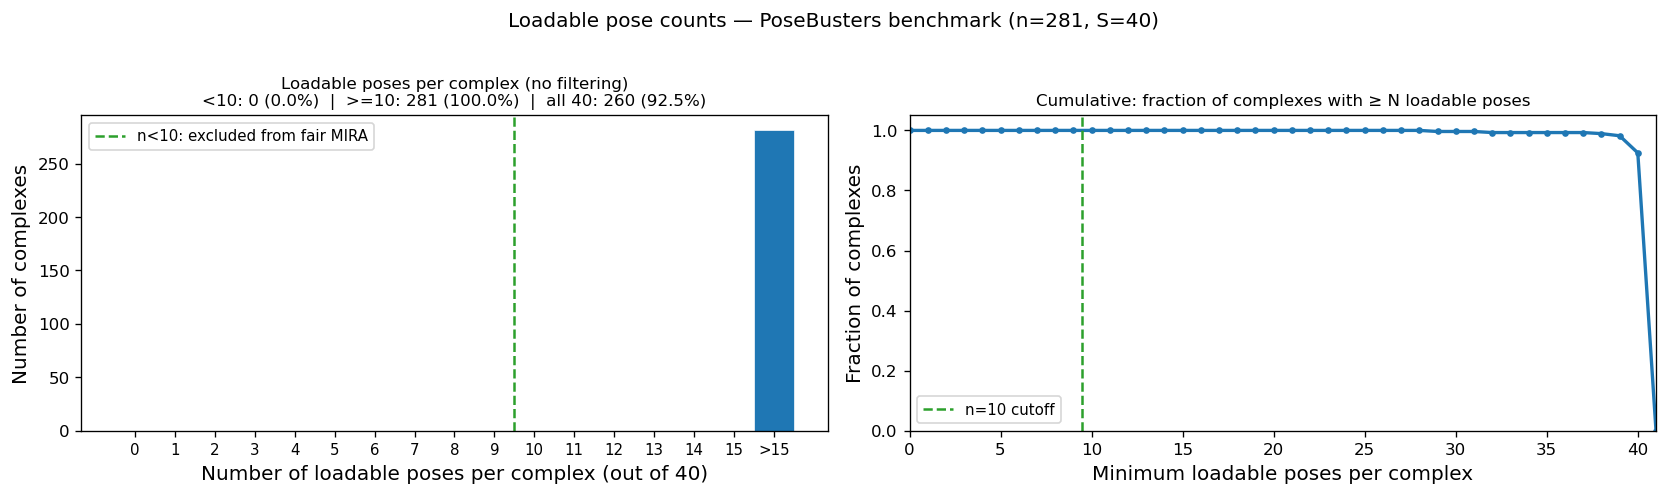

Min: 28  Max: 40  Mean: 39.8
All 40 poses: 260 (92.5%)
Fewer than 10: 0 (0.0%)


In [11]:
from utils.tarp_eval import load_sample_coords

n_loadable = np.array([len(load_sample_coords(n, results_index)) for n in complex_names])

CUTOFF = 15
bins = np.arange(-0.5, CUTOFF + 2.5, 1)
tick_positions = list(range(CUTOFF + 2))
tick_labels    = [str(i) for i in range(CUTOFF + 1)] + [f'>{CUTOFF}']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram of loadable pose counts
n_load_clipped = np.clip(n_loadable, 0, CUTOFF + 1)
axes[0].hist(n_load_clipped, bins=bins, color='C0', edgecolor='white', linewidth=0.4)
axes[0].axvline(9.5, color='C2', ls='--', lw=1.5, label='n<10: excluded from fair MIRA')
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(tick_labels, fontsize=9)
axes[0].set_xlabel('Number of loadable poses per complex (out of 40)', fontsize=12)
axes[0].set_ylabel('Number of complexes', fontsize=12)
axes[0].set_title(
    f'Loadable poses per complex (no filtering)\n'
    f'<10: {(n_loadable<10).sum()} ({100*(n_loadable<10).mean():.1f}%)  |  '
    f'>=10: {(n_loadable>=10).sum()} ({100*(n_loadable>=10).mean():.1f}%)  |  '
    f'all 40: {(n_loadable==40).sum()} ({100*(n_loadable==40).mean():.1f}%)',
    fontsize=10
)
axes[0].legend(fontsize=9)

# Right: cumulative — fraction of complexes with >= N loadable poses
thresholds = np.arange(0, 42)
frac_above = np.array([(n_loadable >= t).mean() for t in thresholds])
axes[1].plot(thresholds, frac_above, color='C0', lw=2, marker='o', ms=3)
axes[1].axvline(9.5, color='C2', ls='--', lw=1.5, label='n=10 cutoff')
axes[1].set_xlabel('Minimum loadable poses per complex', fontsize=12)
axes[1].set_ylabel('Fraction of complexes', fontsize=12)
axes[1].set_title('Cumulative: fraction of complexes with ≥ N loadable poses', fontsize=10)
axes[1].set_xlim(0, 41)
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)

plt.suptitle(
    f'Loadable pose counts — PoseBusters benchmark (n={len(complex_names)}, S=40)',
    y=1.02
)
plt.tight_layout()
plt.savefig(f"{FIGURES}/pose_counts.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Min: {n_loadable.min()}  Max: {n_loadable.max()}  Mean: {n_loadable.mean():.1f}")
print(f"All 40 poses: {(n_loadable==40).sum()} ({100*(n_loadable==40).mean():.1f}%)")
print(f"Fewer than 10: {(n_loadable<10).sum()} ({100*(n_loadable<10).mean():.1f}%)")

## Comparison with PDBBind test set

Side-by-side TARP ECP and MIRA violin for PoseBusters vs the PDBBind test set (n=322). Loads pre-computed metrics from the PDBBind run — no recomputation needed.

PDBBind RMSD TARP: 321 complexes, ATC=+0.0024
PDBBind MIRA: 322 complexes, mean=0.6180


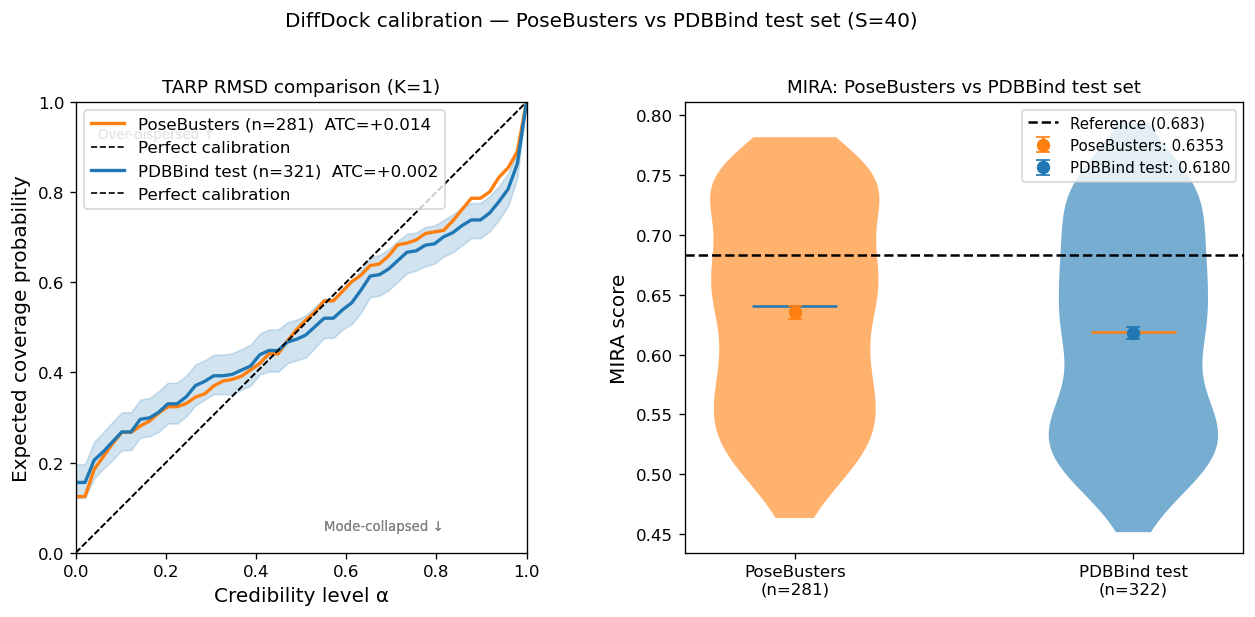

In [12]:
# Allow this cell to run standalone after a kernel restart
if "METRICS" not in dir():
    import sys, os
    sys.path.insert(0, '..')
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib
    from pathlib import Path
    matplotlib.rcParams['figure.dpi'] = 120
    from utils.tarp_eval import (
        run_tarp_eval, ecp_from_fractions, plot_ecp, atc_score, bootstrap_ecp
    )
    from utils.mira_eval import compute_mira_scores, mira_null

    RESULTS_DIR = "/home/qf226/rds/hpc-work/results/DiffDock/pb_evaluate_v2_merged"
    DATA_DIR    = "/home/qf226/rds/hpc-work/data/posebusters_benchmark_set"
    METRICS     = os.path.join(RESULTS_DIR, "metrics")
    FIGURES     = os.path.join(RESULTS_DIR, "figures")
    os.makedirs(METRICS, exist_ok=True)
    os.makedirs(FIGURES, exist_ok=True)

    results_index = {
        d.name: d
        for d in sorted(Path(RESULTS_DIR).iterdir())
        if d.is_dir() and any(d.glob("rank*.sdf"))
    }
    complex_names = np.array(sorted(results_index.keys()))

if "ecp_r" not in dir():
    K_RMSD = 1
    RMSD_CACHE = f"{METRICS}/tarp_fractions_rmsd_K{K_RMSD}.npy"
    f_rmsd = np.load(RMSD_CACHE)
    ecp_r, alpha_r = ecp_from_fractions(f_rmsd, n_bins=50)
    boot_r = bootstrap_ecp(f_rmsd, n_bootstrap=500)
    atc_r  = atc_score(ecp_r, alpha_r)

if "mira_scores" not in dir():
    mira_scores = np.load(f"{METRICS}/mira_scores_rmsd.npy")
    REF = mira_null(S=40)

# ── comparison plot ──────────────────────────────────────────────────────────
PDBBIND_METRICS = "/home/qf226/rds/hpc-work/results/DiffDock/pdbbind_testset/metrics"
K_RMSD = 1  # ensure defined when cell runs in sequence after tarp-rmsd cell

pdbbind_f_rmsd = None
pdbbind_mira   = None

rmsd_path = f"{PDBBIND_METRICS}/tarp_fractions_rmsd_K{K_RMSD}.npy"
mira_path = f"{PDBBIND_METRICS}/mira_scores_rmsd.npy"

if os.path.exists(rmsd_path):
    pdbbind_f_rmsd = np.load(rmsd_path)
    pdbbind_ecp_r, pdbbind_alpha_r = ecp_from_fractions(pdbbind_f_rmsd, n_bins=50)
    print(f"PDBBind RMSD TARP: {pdbbind_f_rmsd.shape[0]} complexes, "
          f"ATC={atc_score(pdbbind_ecp_r, pdbbind_alpha_r):+.4f}")

if os.path.exists(mira_path):
    pdbbind_mira = np.load(mira_path)
    print(f"PDBBind MIRA: {len(pdbbind_mira)} complexes, mean={pdbbind_mira.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Left: TARP RMSD overlay
ax = axes[0]
plot_ecp(ecp_r, alpha_r, ax=ax,
         label=f"PoseBusters (n={len(complex_names)})  ATC={atc_r:+.3f}",
         color="C1")
if pdbbind_f_rmsd is not None:
    atc_pb = atc_score(pdbbind_ecp_r, pdbbind_alpha_r)
    boot_pb = bootstrap_ecp(pdbbind_f_rmsd, n_bootstrap=500)
    plot_ecp(pdbbind_ecp_r, pdbbind_alpha_r, ax=ax,
             label=f"PDBBind test (n={pdbbind_f_rmsd.shape[0]})  ATC={atc_pb:+.3f}",
             color="C0", bootstrap_ecps=boot_pb)
ax.set_title(f"TARP RMSD comparison (K={K_RMSD})", fontsize=11)

# Right: MIRA violin comparison
ax2 = axes[1]
datasets = [(f"PoseBusters\n(n={len(mira_scores)})", mira_scores, "C1")]
if pdbbind_mira is not None:
    datasets.append((f"PDBBind test\n(n={len(pdbbind_mira)})", pdbbind_mira, "C0"))

for i, (label, scores, color) in enumerate(datasets):
    vp = ax2.violinplot([scores], positions=[i], showmedians=True, showextrema=False)
    vp["bodies"][0].set_facecolor(color)
    vp["bodies"][0].set_alpha(0.6)
    ax2.errorbar(i, scores.mean(), yerr=scores.std() / np.sqrt(len(scores)),
                 fmt="o", color=color, capsize=4, ms=7, zorder=5,
                 label=f"{label.split(chr(10))[0]}: {scores.mean():.4f}")

ax2.axhline(REF, color="k", ls="--", lw=1.5, label=f"Reference ({REF:.3f})")
ax2.set_xticks(range(len(datasets)))
ax2.set_xticklabels([d[0] for d in datasets], fontsize=10)
ax2.set_ylabel("MIRA score", fontsize=12)
ax2.set_title("MIRA: PoseBusters vs PDBBind test set", fontsize=11)
ax2.legend(fontsize=9)

plt.suptitle(
    "DiffDock calibration — PoseBusters vs PDBBind test set (S=40)",
    y=1.02, fontsize=12
)
plt.tight_layout()
plt.savefig(f"{FIGURES}/calibration_comparison.png", dpi=150, bbox_inches='tight')
plt.show()